# Image Features Analysis for Brain Tumor Classification

This notebook analyzes the **`image_features`** modality only, the goal is to evaluate how well the **deep ResNet image embeddings** alone can classify the 5 tumor classes.

For each patient:
- i load the available MRI modalities: `ax_t1`, `ax_t1c`, `ax_t2`, `ax_t2f`
- each modality contributes a 2048-dimensional feature vector
- concatenate the modality vectors into a single patient-level representation
- use zero vectors for missing modalities
- append 4 binary indicators to show which modalities are present

This gives a fixed-length feature vector of:

- `4 × 2048 = 8192` embedding features
- `+ 4` modality-presence indicators
- total: **8196 features per patient**


#### Notebook structure

1. Load the dataset splits  
2. Explore the content of `image_features`  
3. Build patient-level feature matrices  
4. Inspect class imbalance  
5. Train baseline classifiers  
6. Compare validation performance  
7. Interpret the results  


In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import LinearSVC

## 1. Paths

Update `DATASET_DIR` if the local path is different.


In [19]:
# Paths
load_dotenv()

DATASET_DIR = os.getenv("DATASET_PATH")

if not DATASET_DIR:
    raise ValueError("DATASET_PATH not set in .env file")

print("DATASET_PATH:", DATASET_DIR)

TRAIN_JSON = os.path.join(DATASET_DIR, "train.json")
VAL_JSON   = os.path.join(DATASET_DIR, "val.json")
IMAGE_ROOT = os.path.join(DATASET_DIR, "image_features", "image_features")

MODALITIES = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]
FEATURE_DIM = 2048

DATASET_PATH: /Users/myriamakrout/Documents/HKU/courses/SDST3612/project/project 12:04/kaggle-dataset 12:04


## 2. Load the official train and validation splits

The JSON files contain the patient IDs and their labels (`Overall_class`) for train and validation.


In [20]:
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_data = json.load(f)

print(f"Train cases: {len(train_data)}")
print(f"Val cases:   {len(val_data)}")

Train cases: 1983
Val cases:   283


## 3. Quick inspection of the image feature files

Each patient may have up to 4 MRI modalities:
- `ax_t1`
- `ax_t1c`
- `ax_t2`
- `ax_t2f`

Each available modality contains one file called `image.npy`, which should be a 2048-dimensional NumPy vector.


In [21]:
def inspect_case(case_id):
    case_dir = os.path.join(IMAGE_ROOT, str(case_id))
    info = []

    for mod in MODALITIES:
        npy_path = os.path.join(case_dir, mod, "image.npy")
        exists = os.path.exists(npy_path)
        shape = None
        dtype = None

        if exists:
            arr = np.load(npy_path)
            shape = arr.shape
            dtype = arr.dtype

        info.append({
            "case_id": str(case_id),
            "modality": mod,
            "exists": exists,
            "shape": shape,
            "dtype": str(dtype) if dtype is not None else None
        })

    return pd.DataFrame(info)

# Example: inspect the first case in train.json
first_case_id = next(iter(train_data.keys()))
inspect_case(first_case_id)

,case_id,modality,exists,shape,dtype
0,7,ax_t1,True,"(2048,)",float32
1,7,ax_t1c,True,"(2048,)",float32
2,7,ax_t2,True,"(2048,)",float32
3,7,ax_t2f,True,"(2048,)",float32


## 4. Modality availability across the dataset

This cell checks how many cases contain each MRI modality.


In [22]:
def modality_availability(split_dict):
    rows = []

    for case_id in split_dict.keys():
        case_dir = os.path.join(IMAGE_ROOT, str(case_id))
        row = {"case_id": str(case_id)}

        for mod in MODALITIES:
            npy_path = os.path.join(case_dir, mod, "image.npy")
            row[mod] = int(os.path.exists(npy_path))

        rows.append(row)

    df = pd.DataFrame(rows)
    return df

train_modality_df = modality_availability(train_data)
val_modality_df = modality_availability(val_data)

print("Train modality availability:")
print(train_modality_df[MODALITIES].sum())

print("\nValidation modality availability:")
print(val_modality_df[MODALITIES].sum())

Train modality availability:
ax_t1     1983
ax_t1c    1899
ax_t2     1871
ax_t2f    1789
dtype: int64

Validation modality availability:
ax_t1     283
ax_t1c    270
ax_t2     269
ax_t2f    249
dtype: int64


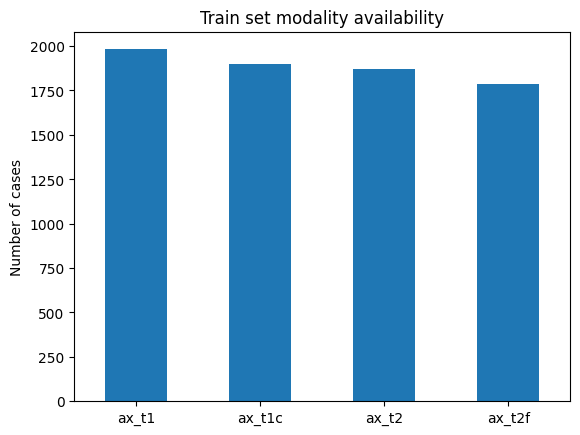

In [23]:
train_modality_df[MODALITIES].sum().plot(kind="bar", title="Train set modality availability", rot=0)
plt.ylabel("Number of cases")
plt.show()

## 5. Build patient-level image feature vectors

### Strategy
For each patient:
- if a modality exists, load its 2048-dimensional embedding
- if a modality is missing, use a zero vector of length 2048
- add 4 binary indicators at the end to tell the model which modalities are present

This preserves a fixed input size for all patients.

### Why use zeros for missing modalities?
The missingness here happens at the **whole-modality level**, not just for isolated feature values.  
Using a mean vector would artificially create a “typical” MRI embedding for a modality that was never acquired.  
Zero-filling plus explicit **presence indicators** is a simple baseline.


In [24]:
def load_case_image_features(case_id: str) -> np.ndarray:
    """
    Build one patient-level feature vector from image_features only.

    Strategy:
    - For each modality in [ax_t1, ax_t1c, ax_t2, ax_t2f]:
        * if available: load its 2048-d feature vector
        * if missing: use a zero vector of length 2048
    - Add 4 binary indicators at the end for modality presence
    """
    case_dir = os.path.join(IMAGE_ROOT, str(case_id))

    modality_vectors = []
    modality_presence = []

    for mod in MODALITIES:
        npy_path = os.path.join(case_dir, mod, "image.npy")
        if os.path.exists(npy_path):
            vec = np.load(npy_path).astype(np.float32)
            if vec.shape != (FEATURE_DIM,):
                raise ValueError(f"Unexpected shape for {npy_path}: {vec.shape}")
            modality_vectors.append(vec)
            modality_presence.append(1.0)
        else:
            modality_vectors.append(np.zeros(FEATURE_DIM, dtype=np.float32))
            modality_presence.append(0.0)

    x = np.concatenate(
        modality_vectors + [np.array(modality_presence, dtype=np.float32)],
        axis=0
    )
    return x

def build_xy(split_dict: dict, has_label: bool = True):
    X, y, case_ids = [], [], []

    for case_id, record in split_dict.items():
        x = load_case_image_features(case_id)
        X.append(x)
        case_ids.append(case_id)

        if has_label:
            y.append(record["Overall_class"])

    X = np.vstack(X)
    y = np.array(y) if has_label else None
    return X, y, case_ids

X_train, y_train, train_ids = build_xy(train_data, has_label=True)
X_val, y_val, val_ids = build_xy(val_data, has_label=True)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)

X_train shape: (1983, 8196)
X_val shape:   (283, 8196)


The expected shape is:
- `X_train = (1983, 8196)`
- `X_val = (283, 8196)`

because each patient is represented by:
- 8192 embedding values
- 4 modality-presence indicators


## 6. Class imbalance

Before training, it is important to inspect the class distribution.


In [25]:
train_counts = pd.Series(y_train).value_counts()
val_counts = pd.Series(y_val).value_counts()

print("Train class distribution:")
print(train_counts)

print("\nVal class distribution:")
print(val_counts)

Train class distribution:
Glioma                                     924
Meningioma                                 728
Brain Metastase Tumour                     252
Tumors of the sellar region                 56
Pineal tumour and Choroid plexus tumour     23
Name: count, dtype: int64

Val class distribution:
Glioma                                     132
Meningioma                                 104
Brain Metastase Tumour                      36
Tumors of the sellar region                  8
Pineal tumour and Choroid plexus tumour      3
Name: count, dtype: int64


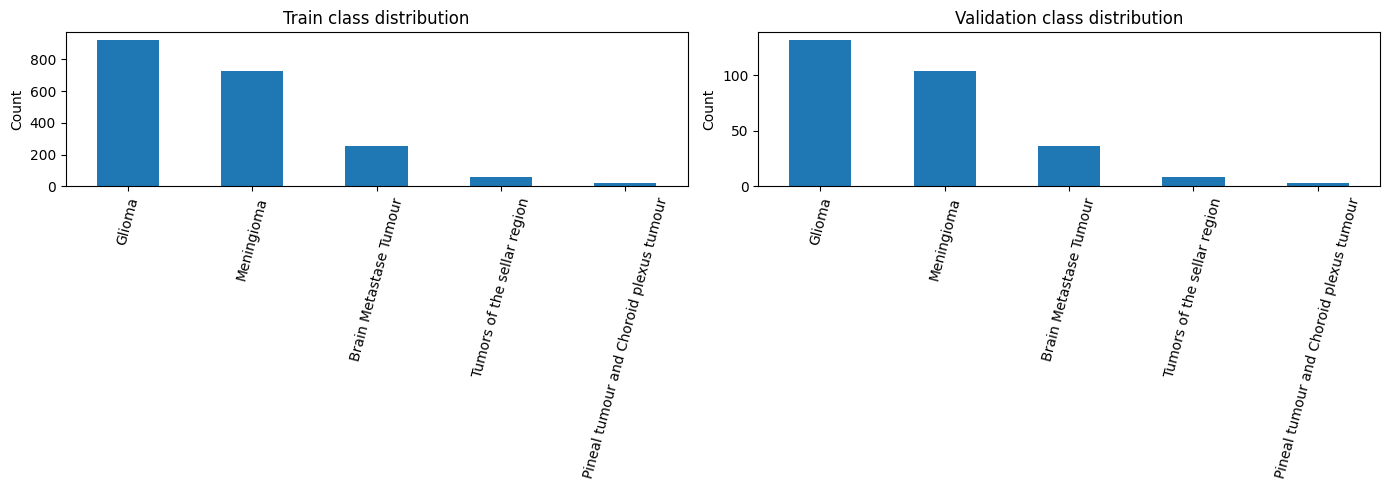

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts.plot(kind="bar", ax=axes[0], title="Train class distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=75)

val_counts.plot(kind="bar", ax=axes[1], title="Validation class distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

The dataset is strongly imbalanced:
- **Glioma** and **Meningioma** dominate
- **Tumors of the sellar region** and **Pineal / Choroid plexus tumour** are rare

This is why `class_weight="balanced"` is used in the linear models.


## 7. Baseline models

We compare four baseline classifiers:

1. **Logistic Regression**  
2. **Linear SVM (LinearSVC)**  
3. **Random Forest**  
4. **Extra Trees**

### Why include both linear and tree-based models?
The ResNet embeddings are already high-level features in a high-dimensional space, so linear models may work well.  
Tree models are still worth testing as a baseline comparison.


In [27]:
models = {
    "logreg_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]),

    "linear_svc_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            class_weight="balanced",
            max_iter=5000
        ))
    ]),

    "random_forest_balanced": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),

    "extra_trees_balanced": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
}

## 8. Train and evaluate the models

We report three metrics:
- **Macro-F1**: treats all classes equally
- **Weighted-F1**: weights classes by size
- **Micro-F1**: close to overall accuracy in this multiclass setting

Here, **Macro-F1** is the most informative measure because the classes are imbalanced.


In [28]:
results = []
best_model_name = None
best_model = None
best_pred = None
best_macro_f1 = -1.0

for name, model in models.items():
    print(f"Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    micro_f1 = f1_score(y_val, y_pred, average="micro")

    results.append({
        "model": name,
        "f1_macro": macro_f1,
        "f1_weighted": weighted_f1,
        "f1_micro": micro_f1,
    })

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model_name = name
        best_model = model
        best_pred = y_pred

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

Training: logreg_balanced
Training: linear_svc_balanced
Training: random_forest_balanced
Training: extra_trees_balanced


,model,f1_macro,f1_weighted,f1_micro
1,linear_svc_balanced,0.461723,0.593160,0.597173
0,logreg_balanced,0.456946,0.599727,0.600707
3,extra_trees_balanced,0.303887,0.536169,0.586572
2,random_forest_balanced,0.240537,0.494561,0.554770


## 9. Validation results obtained

From the current run, the results are:

| Model | Macro-F1 | Weighted-F1 | Micro-F1 |
|---|---:|---:|---:|
| linear_svc_balanced | 0.4617 | 0.5932 | 0.5972 |
| logreg_balanced | 0.4552 | 0.5959 | 0.5972 |
| extra_trees_balanced | 0.3039 | 0.5362 | 0.5866 |
| random_forest_balanced | 0.2405 | 0.4946 | 0.5548 |

### Main observation
The best model is **Linear SVC**, with a **validation macro-F1 of 0.4617**.


In [29]:
print(f"Best model: {best_model_name}")
print(f"Best validation macro-F1: {best_macro_f1:.4f}")

print("\nClass-wise report for best model:")
print(classification_report(y_val, best_pred, digits=4))

Best model: linear_svc_balanced
Best validation macro-F1: 0.4617

Class-wise report for best model:
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.3000    0.3333    0.3158        36
                                 Glioma     0.6393    0.5909    0.6142       132
                             Meningioma     0.6581    0.7404    0.6968       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.3333    0.1250    0.1818         8

                               accuracy                         0.5972       283
                              macro avg     0.5862    0.4246    0.4617       283
                           weighted avg     0.5982    0.5972    0.5932       283



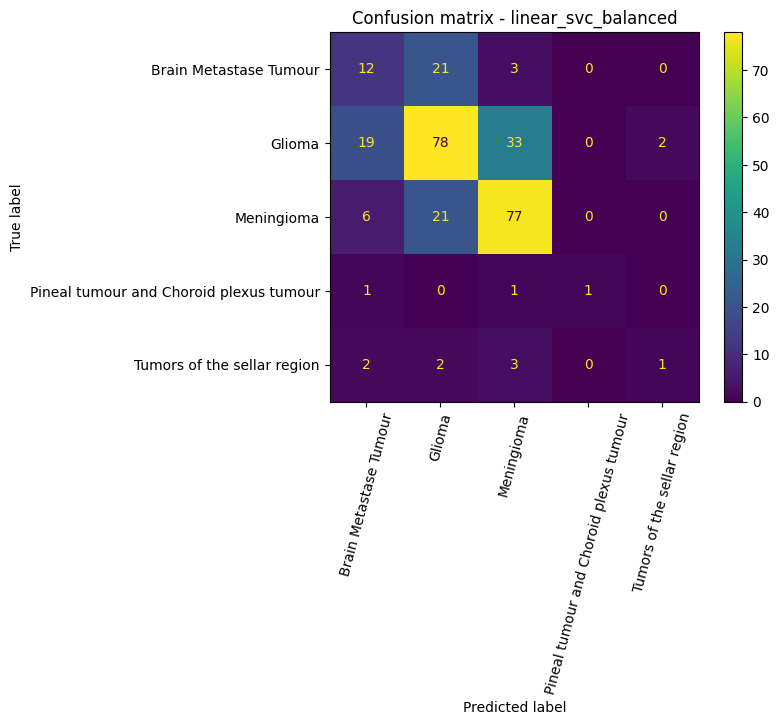

In [30]:
ConfusionMatrixDisplay.from_predictions(y_val, best_pred, xticks_rotation=75)
plt.title(f"Confusion matrix - {best_model_name}")
plt.show()

## 10. Interpretation of the results

### Why do the linear models perform best?
The image features are **ResNet embeddings**, which are already high-level representations.  
This makes the problem more similar to a **high-dimensional tabular classification task** than to raw-image learning.

In this setting:
- linear models can separate classes effectively
- tree-based models may struggle with many dimensions and relatively limited sample size

### Class-wise interpretation
From the best model:
- **Meningioma** has the strongest F1-score
- **Glioma** is also classified reasonably well
- **Brain Metastase Tumour** is more difficult
- **Tumors of the sellar region** is the hardest class
- **Pineal / Choroid plexus tumour** has very few samples, so its score is unstable

### Main limitation
The model performs much better on the **majority classes** than on the rare ones, which shows the strong impact of class imbalance.


## 11. Final conclusion

Using **only the deep image features**:
- the best tested classifier is a **class-balanced Linear SVM**
- the validation **macro-F1 is 0.4617**
- the model captures useful signal from the image embeddings
- performance is strongest for the dominant tumor classes
- performance on rare classes remains weak

### Takeaway
The `image_features` modality alone is informative, but it is **not sufficient** to achieve top competition performance.  
It provides a meaningful unimodal baseline and motivates later **multimodal fusion** with radiomics, clinical data, and report text.


In [32]:
# Save arrays for sharing
SAVE_DIR = os.path.join("Myriam", "processed_data")
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(os.path.join(SAVE_DIR, "X_train.npy"), X_train)
np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)

np.save(os.path.join(SAVE_DIR, "X_val.npy"), X_val)
np.save(os.path.join(SAVE_DIR, "y_val.npy"), y_val)

print("Saved files in:", SAVE_DIR)

Saved files in: Myriam/processed_data
